# Multi-channel morphology prediction

Here we explore multi-channel morphology prediction using SKLearn models. We explore a range of feature sets.

## Labels

In [23]:
import pandas as pd

labels = pd.read_csv('../data/cpg0016/version_2024-04-15/gene_channel_labels.csv')
labels

,Metadata_Symbol,Metadata_NCBI_Gene_ID,Mito,ER,RNA,AGP,DNA
0,A2M,2,Positive,Inteterminate,Inteterminate,Negative,Positive
1,A3GALT2,127550,Inteterminate,Positive,Positive,Positive,Positive
2,A4GALT,53947,Positive,Positive,Positive,Positive,Positive
3,A4GNT,51146,Positive,Inteterminate,Positive,Inteterminate,Inteterminate
4,AACS,65985,Positive,Positive,Inteterminate,Positive,Positive
...,...,...,...,...,...,...,...
7970,ZSCAN32,54925,Inteterminate,Inteterminate,Inteterminate,Inteterminate,Inteterminate
7971,ZSCAN4,201516,Positive,Positive,Positive,Positive,Positive
7972,ZSCAN5A,79149,Positive,Positive,Positive,Positive,Positive
7973,ZSCAN9,7746,Positive,Positive,Positive,Positive,Positive


In [34]:
# Definitively labeled genes by channel

channels = ['Mito', 'ER', 'RNA', 'AGP', 'DNA']
definite_labels = {
    ch: labels[labels[ch].isin(['Positive', 'Negative'])][['Metadata_Symbol', ch]]
    for ch in channels
}

{ch: df[ch].value_counts() for ch, df in definite_labels.items()}

{'Mito': Mito
 Positive    6193
 Negative     390
 Name: count, dtype: int64,
 'ER': ER
 Positive    6174
 Negative     378
 Name: count, dtype: int64,
 'RNA': RNA
 Positive    5686
 Negative     366
 Name: count, dtype: int64,
 'AGP': AGP
 Positive    5588
 Negative     480
 Name: count, dtype: int64,
 'DNA': DNA
 Positive    5592
 Negative     463
 Name: count, dtype: int64}

In [25]:
label_combinations = labels[channels].value_counts().to_frame()
label_combinations

count
Mito          ER            RNA           AGP           DNA                 
Positive      Positive      Positive      Positive      Positive        4131
                                                        Inteterminate    438
                                          Inteterminate Positive         337
Inteterminate Inteterminate Inteterminate Inteterminate Inteterminate    266
Positive      Inteterminate Inteterminate Inteterminate Positive         201
...                                                                      ...
Inteterminate Positive      Negative      Positive      Negative           1
Negative      Positive      Negative      Positive      Inteterminate      1
                                                        Negative           1
              Inteterminate Inteterminate Negative      Positive           1
Inteterminate Inteterminate Positive      Negative      Positive           1

[164 rows x 1 columns]

In [26]:
label_combinations[label_combinations['count'] > 10]

count
Mito          ER            RNA           AGP           DNA                 
Positive      Positive      Positive      Positive      Positive        4131
                                                        Inteterminate    438
                                          Inteterminate Positive         337
Inteterminate Inteterminate Inteterminate Inteterminate Inteterminate    266
Positive      Inteterminate Inteterminate Inteterminate Positive         201
                                                        Inteterminate    183
Inteterminate Positive      Positive      Positive      Positive         170
                                                        Inteterminate    137
Positive      Positive      Inteterminate Positive      Positive         132
                                          Inteterminate Positive         120
                                                        Inteterminate     92
Inteterminate Inteterminate Inteterminate Inteterminate Positive          86
Positive      Positive      Positive      Inteterminate Inteterminate     77
Negative      Negative      Negative      Negative      Negative          75
Positive      Positive      Inteterminate Positive      Inteterminate     71
              Inteterminate Inteterminate Positive      Positive          67
Inteterminate Inteterminate Inteterminate Negative      Inteterminate     60
              Positive      Inteterminate Inteterminate Inteterminate     56
                            Positive      Inteterminate Inteterminate     46
Positive      Inteterminate Inteterminate Positive      Inteterminate     46
Inteterminate Positive      Inteterminate Positive      Inteterminate     44
                            Positive      Inteterminate Positive          40
                            Inteterminate Positive      Positive          39
Positive      Inteterminate Positive      Inteterminate Positive          37
Inteterminate Negative      Negative      Negative      Inteterminate     36
              Positive      Inteterminate Inteterminate Positive          35
Negative      Positive      Positive      Positive      Negative          35
Inteterminate Inteterminate Inteterminate Positive      Inteterminate     34
Positive      Inteterminate Positive      Positive      Positive          32
Inteterminate Negative      Negative      Negative      Negative          32
Negative      Negative      Negative      Negative      Inteterminate     30
Positive      Positive      Positive      Positive      Negative          27
Negative      Inteterminate Inteterminate Inteterminate Inteterminate     27
Inteterminate Inteterminate Inteterminate Inteterminate Negative          26
Positive      Inteterminate Positive      Inteterminate Inteterminate     26
                            Inteterminate Negative      Inteterminate     24
Inteterminate Inteterminate Inteterminate Positive      Positive          22
                                          Negative      Positive          21
                            Positive      Inteterminate Positive          21
Negative      Positive      Positive      Positive      Inteterminate     18
Inteterminate Positive      Positive      Positive      Negative          18
              Negative      Inteterminate Inteterminate Inteterminate     18
Positive      Inteterminate Inteterminate Inteterminate Negative          17
Inteterminate Inteterminate Positive      Inteterminate Inteterminate     16
Negative      Positive      Inteterminate Positive      Negative          15
Positive      Inteterminate Inteterminate Negative      Positive          14
Inteterminate Negative      Negative      Inteterminate Inteterminate     14
Negative      Inteterminate Inteterminate Negative      Negative          13
Inteterminate Negative      Inteterminate Negative      Inteterminate     13
Negative      Negative      Negative      Negative      Positive          11
                                          Inteterminate Negative   

## Feature data sources

In [27]:
# Gene abundances
cell_line_df = pd.read_table('../../../data/cellular-localization/gene_abundances_U2OS.tsv')
cell_line_df

,Enesembl ID,Gene,RNA line ab,RNA type ab,protein type ab
0,ENSG00000000003,TSPAN6,23.4,NaN,NaN
1,ENSG00000000005,TNMD,0.0,NaN,NaN
2,ENSG00000000419,DPM1,97.8,NaN,NaN
3,ENSG00000000457,SCYL3,3.6,NaN,NaN
4,ENSG00000000460,C1orf112,16.1,NaN,NaN
...,...,...,...,...,...
20077,ENSG00000288677,AC105206.4,1.7,NaN,NaN
20078,ENSG00000288678,AL136115.4,0.0,NaN,NaN
20079,ENSG00000288681,AC136475.9,0.0,NaN,NaN
20080,ENSG00000288684,AL353671.1,0.7,NaN,NaN


In [28]:
# Undetected genes
undetected_df = pd.read_table('../../../data/cellular-localization/undetected_genes_U2OS.tsv')
undetected_df

,Enesembl ID,Gene
0,ENSG00000159455,LCE2B
1,ENSG00000141255,SPATA22
2,ENSG00000259303,IGHV2OR16-5
3,ENSG00000186930,KRTAP6-2
4,ENSG00000211967,IGHV3-53
...,...,...
4041,ENSG00000142973,CYP4B1
4042,ENSG00000188120,DAZ1
4043,ENSG00000111783,RFX4
4044,ENSG00000188730,VWC2


We will use the `RNA line ab` column and encode protein absence with a binary variable (absent=0, present=1):

In [29]:
abundance_df = cell_line_df[['Gene', 'RNA line ab']]
abundance_df.loc[:, 'Protein present'] = 1
abundance_df.loc[abundance_df['Gene'].isin(undetected_df['Gene']), 'Protein present'] = 0
abundance_df

/tmp/ipykernel_3816553/2725172607.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abundance_df.loc[:, 'Protein present'] = 1


,Gene,RNA line ab,Protein present
0,TSPAN6,23.4,1
1,TNMD,0.0,0
2,DPM1,97.8,1
3,SCYL3,3.6,1
4,C1orf112,16.1,1
...,...,...,...
20077,AC105206.4,1.7,1
20078,AL136115.4,0.0,0
20079,AC136475.9,0.0,0
20080,AL353671.1,0.7,1


In [30]:
# Subcellular localization data
sc_df = (
    pd
    .read_table(
        '../../../data/subcellular-localization/uniprot_reactome_hpa_merged.tsv',
        usecols=['gene_id', 'hpa_location']
    )
    .drop_duplicates()
    .pivot_table(index='gene_id', columns='hpa_location', aggfunc=lambda _: 1, fill_value=0)
)
sc_df

hpa_location,actin filaments:cytoplasm,aggresome:cytosol:cytoplasm,cell junctions:plasma membrane:endomembrane system,centriolar satellite:centrosome:cytoplasm,centrosome:cytoplasm,cleavage furrow:actin filaments:cytoplasm,cytokinetic bridge:microtubules:cytoplasm,cytoplasm,cytoplasmic bodies:cytosol:cytoplasm,cytosol:cytoplasm,...,nucleoli rim:nucleoli:nucleus,nucleoli:nucleus,nucleoplasm:nucleus,nucleus,peroxisomes:vesicles:endomembrane system,plasma membrane:endomembrane system,rods & rings:cytosol:cytoplasm,secreted proteins:secretory,secretory,vesicles:endomembrane system
gene_id,,,,,,,,,,,,,,,,,,,,,
1C,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1a,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3a,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,1
3b,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vpr,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
vpu,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,1,0
wnt11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [31]:
# GO embeddings
go_embedding = pd.read_csv('../../../data/GO_Embeddings/go_embedding_64.csv', index_col=0)
go_embedding

,go_feature_0,go_feature_1,go_feature_2,go_feature_3,go_feature_4,go_feature_5,go_feature_6,go_feature_7,go_feature_8,go_feature_9,...,go_feature_54,go_feature_55,go_feature_56,go_feature_57,go_feature_58,go_feature_59,go_feature_60,go_feature_61,go_feature_62,go_feature_63
A1BG,-0.367388,-0.413445,-0.404171,-0.004415,0.247503,-0.102804,0.157222,0.135817,0.089900,0.074568,...,0.292506,0.002101,0.263603,0.169054,0.063430,-0.171397,0.077323,0.051098,-0.082001,-0.036673
ABG,-0.158945,-0.490194,-0.403563,-0.029135,0.218117,-0.182563,0.094209,0.367191,0.190919,0.060625,...,0.354492,0.080943,0.412824,0.237152,0.164620,-0.067162,0.131368,-0.198871,-0.009133,-0.123394
GAB,-0.180069,-0.461517,-0.384918,0.124994,0.370956,-0.238049,-0.142643,0.268287,0.099368,-0.046293,...,0.083225,0.151852,0.395230,0.325642,0.009123,0.005238,0.014833,-0.086011,-0.110260,-0.070421
HYST2477,-0.264915,-0.487703,-0.230273,-0.033565,0.199071,-0.205979,0.118402,0.201433,0.175869,0.112664,...,0.110051,0.018307,0.547518,0.345197,0.265257,-0.011448,-0.016393,-0.227499,-0.241314,-0.233270
AGP-B,-0.503596,-0.640465,-0.509292,0.149607,0.393729,-0.390091,0.261283,0.243027,0.251378,-0.035333,...,0.491511,0.201053,0.626971,0.418596,0.004392,0.176189,0.066519,-0.039353,0.027906,-0.251306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BECN2,0.244011,-0.263258,-0.058161,0.086946,-0.049276,0.201113,-0.158159,-0.080029,0.105038,-0.029396,...,0.111178,0.110147,0.376339,0.228923,-0.087186,0.278534,-0.173626,-0.059988,0.162028,-0.135971
BECN1L1,0.232987,-0.238887,0.152314,0.086158,0.211937,0.196062,-0.173626,0.207144,0.054919,-0.048840,...,0.261120,-0.020350,0.431131,0.151029,0.037241,0.242878,-0.135145,-0.076569,0.097100,-0.015145
BECN1P1,0.203444,-0.165649,-0.144183,0.142063,0.079616,0.128623,-0.151379,-0.144399,0.001635,0.177796,...,0.199253,-0.054431,0.236613,-0.019560,-0.047433,0.272289,-0.071594,0.187233,-0.104395,0.001068
SULT1C3,0.061440,0.042919,-0.101767,0.142327,0.153482,0.057794,-0.162811,0.157489,0.196053,-0.061985,...,0.026004,-0.056475,0.208966,-0.208943,-0.094607,-0.046538,-0.100566,0.038614,-0.121547,0.020993


## Assembling labeled sets

In [33]:
# For each channel we assemble a dataset that is definitively labeled for that channel
labeled_dfs = {
    ch: label_df
        .merge(
            abundance_df,
            how='inner',
            left_on='Metadata_Symbol',
            right_on='Gene'
        )
        .merge(
            sc_df,
            how='inner',
            left_on='Metadata_Symbol',
            right_index=True
        )
        .merge(
            go_embedding,
            how='inner',
            left_on='Metadata_Symbol',
            right_index=True
        )
    for ch, label_df in definite_labels.items()
}

{ch: df[ch].value_counts() for ch, df in labeled_dfs.items()}

{'Mito': Mito
 Positive    5726
 Negative     357
 Name: count, dtype: int64,
 'ER': ER
 Positive    5723
 Negative     352
 Name: count, dtype: int64,
 'RNA': RNA
 Positive    5258
 Negative     335
 Name: count, dtype: int64,
 'AGP': AGP
 Positive    5187
 Negative     438
 Name: count, dtype: int64,
 'DNA': DNA
 Positive    5183
 Negative     423
 Name: count, dtype: int64}

In [43]:
id_cols = ['Metadata_Symbol', 'Gene']

In [44]:
# Tables for ML
ml_dfs = {
    ch: (df[df.columns.drop(id_cols + [ch])], df[ch].map({'Positive': 1, 'Negative': 0}))
    for ch, df in labeled_dfs.items()
}

## Model evaluation

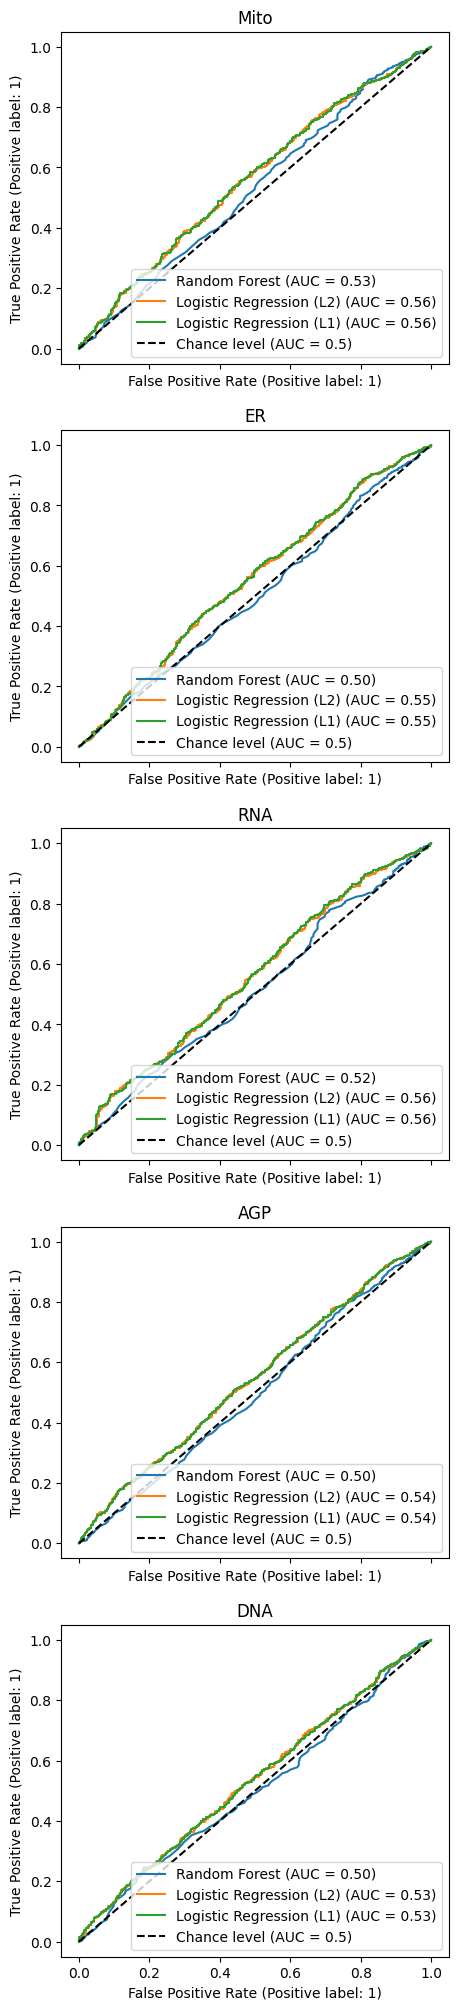

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.metrics import roc_curve, auc, accuracy_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize, LabelEncoder
from matplotlib.pyplot import subplots

models = {
    'Random Forest': RandomForestClassifier(n_estimators=1000),
    'Logistic Regression (L2)':
        Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(penalty='l2', max_iter=30000))
        ]),
    'Logistic Regression (L1)':
        Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(penalty='l1', solver='liblinear', max_iter=30000))
        ])
}

cv = StratifiedKFold(n_splits=3, random_state=20240416, shuffle=True)

nmodels = len(models)
nrows = len(ml_dfs)
fig, ax = subplots(nrows=nrows, ncols=1, sharex=True, sharey=True, squeeze=False, figsize=(5,5*nrows))

for i_m, (name, model) in enumerate(models.items()):
    for i_c, (channel, (x, y)) in enumerate(ml_dfs.items()):
        probs = cross_val_predict(model, x, y, cv=cv, method='predict_proba')[:, 1]
        RocCurveDisplay.from_predictions(y, probs, name=name, plot_chance_level=(i_m==nmodels-1), ax=ax[i_c,0])
        if i_m == 0:
            ax[i_c, 0].set_title(channel)